<a href="https://colab.research.google.com/github/fionastern28/comp-neuro/blob/main/SDH_modeling_summer_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SDH Modeling**


This Colab notebook is an initial attempt at having a workspace.  I have downloaded the initial Medlock et al 2022 code locally on my computer.  I intend to have one github repository.  The repo will contain both this notebook as well as possibly any changes I make to the Medlock code.

My instinct is to do most initial exploratory work in the notebook, but perhaps to move over to a VS Code file structure when working with a more complete model

Below is an attempt to understand the spike time generation

In [ ]:
!pip install neuron netpyne

In [ ]:
from google.colab import files
print("Upload three things: cells.py, genrn.py, and mods.zip")
files.upload()
files.upload()
files.upload()

In [ ]:
!unzip -o mods.zip
!ls           # expect: cells.py  genrn.py  mods/  mods.zip
!ls mods      # expect: a bunch of .mod files (HH2.mod, iCaL.mod, ...)

In [ ]:
!nrnivmodl mods

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


#returns rate of type 1 Aβ touch afferent firing over 1000 ms
def rate_SAI():
    t = [ x for x in np.arange(0, 10001, 1) ]

    rate = []

    for i, key in enumerate(t):
        if i < len(t):
            freq_SAI = (-1.45433609113392e-10 * key ** 3 + 1.340603396708e-6 * key ** 2 - 0.00378224210238498 * key + 4.52737468545426) * 8
            rate.append(freq_SAI)

    return rate, t

#returns rate of type 2 Aβ touch afferent firing over 1000 ms
def rate_SAII():
    t = [ x for x in np.arange(0, 10001, 1) ]

    rate = []

    for i, key in enumerate(t):
        if i < len(t):
            freq_SAII = (-1.45433609113392e-10 * key ** 3 + 1.340603396708e-6 * key ** 2 - 0.00378224210238498 * key + 4.52737468545426) * 8
            rate.append(freq_SAII)

    return rate, t

#returns rate of Ad firing, plugged in 0.25 for cfg.stim_ratios
def rate_Ad():
    t = [ x for x in np.arange(0, 10001, 1) ]

    rate = []

    for i, key in enumerate(t):
        if i < len(t):
            freq_Ad = ( -7.265297e-15 * key ** 4 + 1.573831e-10 * key ** 3 - 8.201529e-7 * key ** 2 - 0.002539930 * key + 27.18412 ) * 0.25
            rate.append(freq_Ad)

    return rate, t

#returns rate of C firing, plugged in 0.25 for cfg.stim_ratios
def rate_C():
    t = [ x for x in np.arange(0, 10001, 1) ]

    rate  = []

    for i, key in enumerate(t):
        if i < len(t):
            freq_C = (  9.630390e-15 * key ** 4 - 2.844577e-10 * key ** 3 + 3.012887e-6 * key ** 2 - 0.01400381 * key + 31.86546 ) * 0.25
            rate.append(freq_C)

    return rate, t

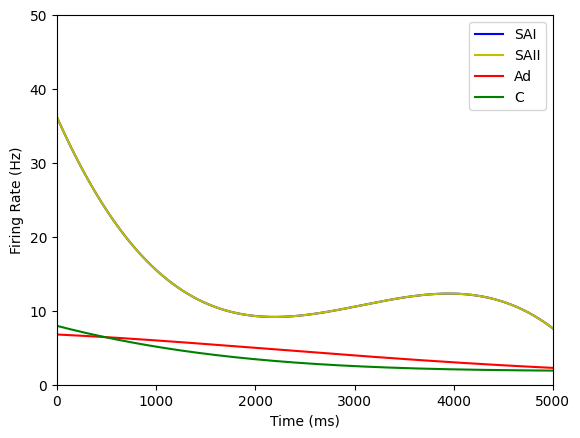

In [ ]:
ratesSAI, timeSAI = rate_SAI()
ratesSAII, timeSAII = rate_SAII()
ratesAd, timeAd = rate_Ad()
ratesC, timeC = rate_C()

# plots the rates of each type of fiber
plt.plot(timeSAI, ratesSAI, label = "SAI", color = 'b')
plt.plot(timeSAII, ratesSAII, label = "SAII", color = 'y')
plt.plot(timeAd, ratesAd, label = "Ad", color = 'r')
plt.plot(timeC, ratesC, label = "C", color = 'g')
plt.xlabel("Time (ms)")
plt.ylabel("Firing Rate (Hz)")

#limits to first 5 seconds (which is all that is relevant to model)
plt.axis([0, 5000, 0,50])
plt.legend()

#can see that both follow the same trajectory

Below is code taken from cells.py, it is a dictionarry, giving the conditions for a pNK1 cell with the three part model.  references mod files... might need those


In [ ]:
PROcellRule = {
 'conds': {},
 'globals': {},
 'secLists': {},
 'secs': {'dend': {'geom': {'L': 350.0, 'nseg': 5, 'diam': 2.5, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'can': {'e': 0.0, 'i': 1.0, 'o': 1.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'CaIntraCellDyn': {'cai_inf': 5e-05,
                                                'cai_tau': 2.0,
                                                'depth': 0.1},
                             'HH2': {'gnabar': 0.0, 'gkbar': 0.036, 'vtraub': -55.0}, # HH1 = 0, Kdr = 36 (fiona).   Hodgkin-Huxley 2?? (hh2)
                             'iCaAN': {'gbar': 9.099999999999999e-05}, # caAN = 0.1 x10^-12 (fiona)
                             'iCaL': {'pcabar': 3e-05}, # CaL = 3.0 x 10^-2 (fiona)
                             'iKCa': {'gbar': 0.001, 'gk': 0.0}, # k_ca = 1, NaP = 0 (fiona)
                             'pas': {'g': 4.2e-05, 'e': -65.0}}, # Leak = 4.2x 10^-2 (fiona)
                   'topol': {'parentSec': 'soma', 'parentX': 0.0, 'childX': 0.0}},
          'hillock': {'geom': {'L': 9.0, 'nseg': 3, 'diam': 1.5, 'Ra': 150.0, 'cm': 1.0},
                      'ions': {'k': {'e': -77.0, 'i': 54.4, 'o': 2.5},
                               'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                      'mechs': {'B_A': {},
                                'HH2': {'gkbar': 0.076,
                                        'gnabar': 3.45,
                                        'vtraub': -55.0},
                                'pas': {'g': 4.2e-05, 'e': -65.0}},
                      'topol': {'parentSec': 'soma', 'parentX': 1.0, 'childX': 0.0}},
          'soma': {'geom': {'L': 20.0, 'nseg': 3, 'diam': 20.0, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'can': {'e': 0.0, 'i': 1.0, 'o': 1.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'CaIntraCellDyn': {'cai_inf': 5e-05,
                                                'cai_tau': 1.0,
                                                'depth': 0.1},
                             'HH2': {'gkbar': 0.001075,
                                     'gnabar': 0.0,
                                     'vtraub': -55.0},
                             'iCaAN': {'gbar': 0.0},
                             'iCaL': {'pcabar': 0.0001},
                             'iKCa': {'gbar': 0.0001, 'gk': 0.0},
                             'iNaP': {'gamma': 0.5,
                                      'gnabar': 0.0001,
                                      'vsh': -5.0,
                                      'vsm': -2.0,
                                      'vtraub': -55.0},
                             'pas': {'g': 4.2e-05, 'e': -65.0}},
                   'topol': {}}}
}

In [ ]:
!pip install netpyne
from netpyne import specs, sim

In [ ]:
# code grabbed from various parts of netParams_mechanical.py


netParams = specs.NetParams() # line from clause
PROcellRule['conds'] = {'cellType': 'PRO'}
PROcellRule['secs']['soma']['threshold'] = 0
netParams.cellParams['NK1Rule'] = cells.PROcellRule
netParams.popParams['NK1'] = {'cellType': 'PRO', 'numCells': 1} # NK1+ neurons (projection)

# first version here: constant input
# following from claude

# IClamp holds 'amp' steady from time 'del' until 'del'+'dur'.
netParams.stimSourceParams['input'] = {
    'type': 'IClamp',
    'del': 100,     # ms: rest first, so you can see baseline
    'dur': 900,     # ms: then hold the current on for the rest of the run
    'amp': 0.1}     # nA: the constant input level  <-- the knob to change


netParams.stimTargetParams['input->NK1'] = {
    'source': 'input', 'conds': {'pop': 'NK1'},
    'sec': 'dend', 'loc': 0.5}







Start time:  2026-06-12 15:34:41.587055




Creating network of 1 cell populations on 1 hosts...:   0%|          |
Creating network of 1 cell populations on 1 hosts...: 100%|##########|

  Number of cells on node 0: 1 
  Done; cell creation time = 0.01 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 1 
  Done; cell stims creation time = 0.00 s.
Recording 3 traces of 3 types on node 0

Running simulation using NEURON for 1000.0 ms...


  Done; run time = 0.57 s; real-time ratio: 1.75.

Gathering data...
  Done; gather time = 0.00 s.

Analyzing...
  Cells: 1
  Connections: 0 (0.00 per cell)
  Spikes: 95 (95.00 Hz)
  Simulated time: 1.0 s; 1 workers
  Run time: 0.57 s
Saving output as data/model_output_data.json ... 
Finished saving!
  Done; saving time = 0.10 s.
Plotting recorded cell traces ... cell


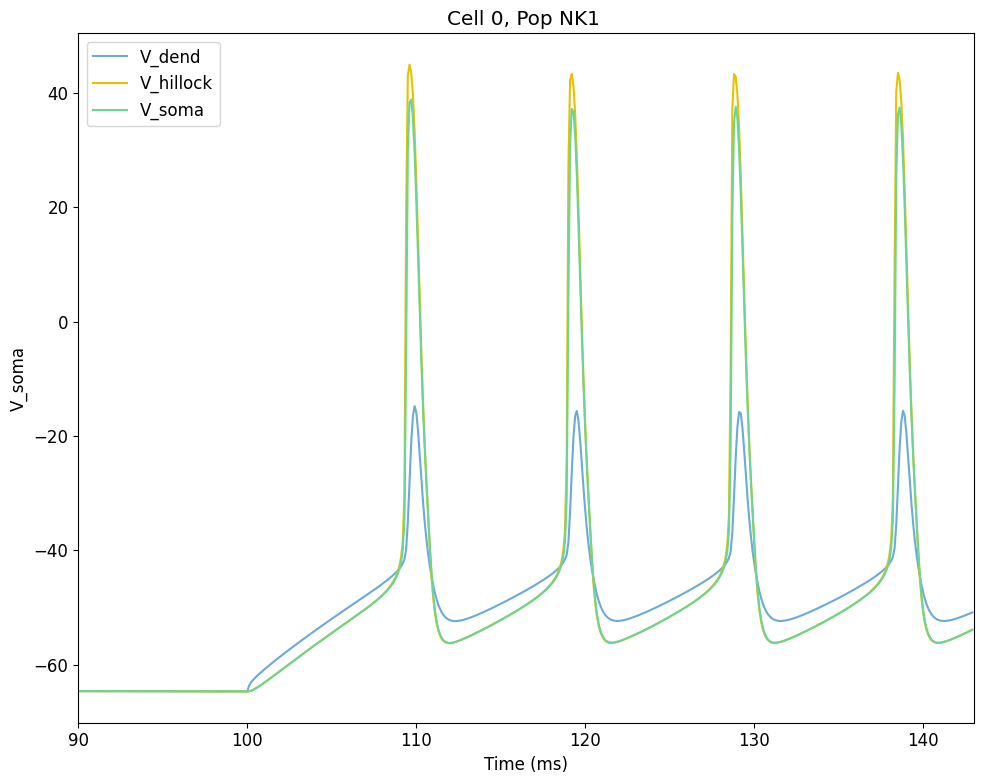

  Done; plotting time = 0.84 s

Total time = 1.52 s


In [ ]:
 # ---- run settings ---- all claude here need to return
cfg = specs.SimConfig()
cfg.hParams    = {'celsius': 36, 'v_init': -60}
cfg.duration   = 1000      # ms
cfg.dt         = 0.025
cfg.recordStep = 0.1
cfg.saveFolder = 'data'     # where output goes
cfg.saveJson   = True       # save results (also clears the "won't be saved" warning)
cfg.recordTraces['V_dend'] = {'sec': 'dend', 'loc': .5, 'var': 'v'}
cfg.recordTraces['V_soma'] = {'sec': 'soma', 'loc': 0.5, 'var': 'v'}
cfg.recordTraces['V_hillock'] = {'sec': 'hillock', 'loc': .5, 'var': 'v'}

# note measures loc. 0.5 on each, but unclear what actual model does should check
%matplotlib inline
cfg.analysis['plotTraces'] = {
    'include': [0],
    'timeRange': [90, 143],     # zoom the x-axis to 100-140 ms
    'overlay': True,           # all traces on a single graph
    'saveFig': True, 'showFig': True}

sim.createSimulateAnalyze(netParams=netParams, simConfig=cfg)

# **DAY 2 modeling the EVGLUT neuron**


Below: HH code from https://github.com/swharden/pyHH/blob/master/dev/concept4.py$0

/tmp/ipykernel_1008/228391832.py:38: RuntimeWarning: overflow encountered in exp
  self.n.alpha = .01 * ((10-Vm) / (np.exp((10-Vm)/10)-1))
/tmp/ipykernel_1008/228391832.py:39: RuntimeWarning: overflow encountered in exp
  self.n.beta = .125*np.exp(-Vm/80)
/tmp/ipykernel_1008/228391832.py:40: RuntimeWarning: overflow encountered in exp
  self.m.alpha = .1*((25-Vm) / (np.exp((25-Vm)/10)-1))
/tmp/ipykernel_1008/228391832.py:41: RuntimeWarning: overflow encountered in exp
  self.m.beta = 4*np.exp(-Vm/18)
/tmp/ipykernel_1008/228391832.py:42: RuntimeWarning: overflow encountered in exp
  self.h.alpha = .07*np.exp(-Vm/20)
/tmp/ipykernel_1008/228391832.py:43: RuntimeWarning: overflow encountered in exp
  self.h.beta = 1/(np.exp((30-Vm)/10)+1)
/tmp/ipykernel_1008/228391832.py:17: RuntimeWarning: invalid value encountered in scalar multiply
  alphaState = self.alpha * (1-self.state)
/tmp/ipykernel_1008/228391832.py:18: RuntimeWarning: invalid value encountered in scalar multiply
  betaState = se

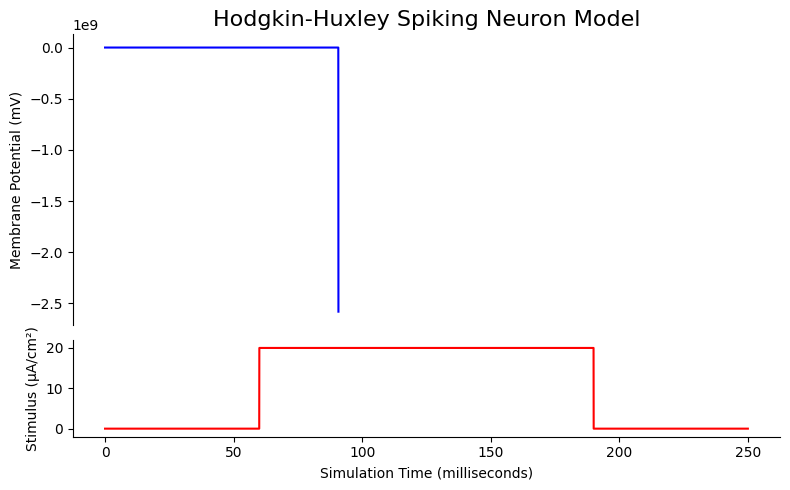

In [ ]:
"""
Python implementation of the Hodgkin-Huxley spiking neuron model
https://github.com/swharden/pyHH
"""
import matplotlib.pyplot as plt
import numpy as np


class HHModel:
    """The HHModel tracks conductances of 3 channels to calculate Vm"""

    class Gate:
        """The Gate object manages a channel's kinetics and open state"""
        alpha, beta, state = 0, 0, 0

        def update(self, deltaTms):
            alphaState = self.alpha * (1-self.state)
            betaState = self.beta * self.state
            self.state += deltaTms * (alphaState - betaState)

        def setInfiniteState(self):
            self.state = self.alpha / (self.alpha + self.beta)

    ENa, EK, EKleak = 50, -70, -65.0
    gNa, gK, gKleak = 0.08548, 0.0043, 0.96e-06
    m, n, h = Gate(), Gate(), Gate()
    Cm = 1

    def __init__(self, startingVoltage=0):
        self.Vm = startingVoltage
        self.UpdateGateTimeConstants(startingVoltage)
        self.m.setInfiniteState()
        self.n.setInfiniteState()
        self.h.setInfiniteState()

    def UpdateGateTimeConstants(self, Vm):
        """Update time constants of all gates based on the given Vm"""
        self.n.alpha = .01 * ((10-Vm) / (np.exp((10-Vm)/10)-1))
        self.n.beta = .125*np.exp(-Vm/80)
        self.m.alpha = .1*((25-Vm) / (np.exp((25-Vm)/10)-1))
        self.m.beta = 4*np.exp(-Vm/18)
        self.h.alpha = .07*np.exp(-Vm/20)
        self.h.beta = 1/(np.exp((30-Vm)/10)+1)

    def UpdateCellVoltage(self, stimulusCurrent, deltaTms):
        """calculate channel currents using the latest gate time constants"""
        INa = np.power(self.m.state, 3) * self.gNa * \
            self.h.state*(self.Vm-self.ENa)
        IK = np.power(self.n.state, 4) * self.gK * (self.Vm-self.EK)
        IKleak = self.gKleak * (self.Vm-self.EKleak)
        Isum = stimulusCurrent - INa - IK - IKleak
        self.Vm += deltaTms * Isum / self.Cm

    def UpdateGateStates(self, deltaTms):
        """calculate new channel open states using latest Vm"""
        self.n.update(deltaTms)
        self.m.update(deltaTms)
        self.h.update(deltaTms)

    def Iterate(self, stimulusCurrent=0, deltaTms=0.05):
        self.UpdateGateTimeConstants(self.Vm)
        self.UpdateCellVoltage(stimulusCurrent, deltaTms)
        self.UpdateGateStates(deltaTms)


if __name__ == "__main__":
    hh = HHModel()
    pointCount = 5000
    voltages = np.empty(pointCount)
    times = np.arange(pointCount) * 0.05
    stim = np.zeros(pointCount)
    stim[1200:3800] = 20  # create a square pulse

    for i in range(len(times)):
        hh.Iterate(stimulusCurrent=stim[i], deltaTms=0.05)
        voltages[i] = hh.Vm
        # note: you could also plot hh's n, m, and k (channel open states)

    f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 5),
                                 gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(times, voltages - 70, 'b')
    ax1.set_ylabel("Membrane Potential (mV)")
    ax1.set_title("Hodgkin-Huxley Spiking Neuron Model", fontsize=16)
    ax1.spines['right'].set_visible(False)
    ax1.spines['top'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax1.tick_params(bottom=False)

    ax2.plot(times, stim, 'r')
    ax2.set_ylabel("Stimulus (µA/cm²)")
    ax2.set_xlabel("Simulation Time (milliseconds)")
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    plt.margins(0, 0.1)
    plt.tight_layout()
   # plt.savefig("dev/concept4.png")
    plt.show()

# **Following code entirely from Claude**

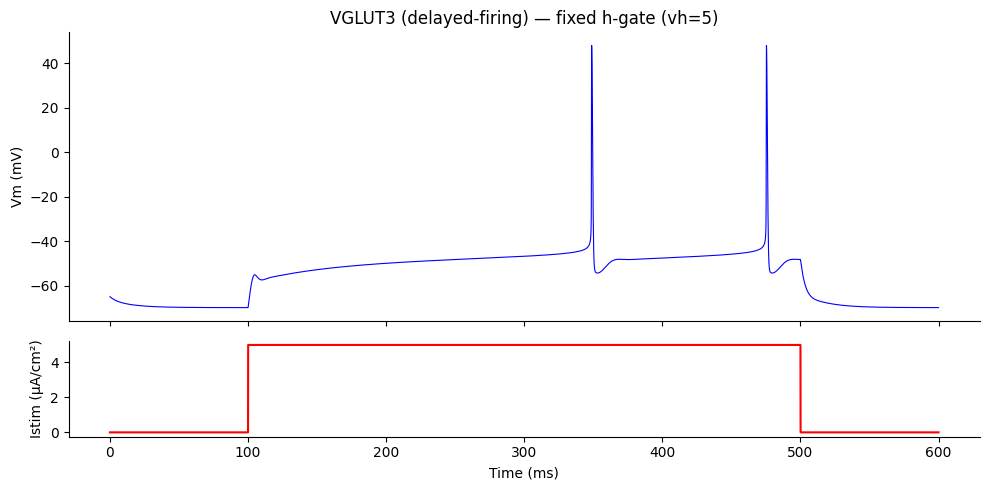

In [ ]:
"""
Single-compartment VGLUT3 (delayed-firing excitatory) spinal dorsal horn neuron.
Soma conductances from Sekiguchi et al. (2021); HH2 kinetics matched to HH2.mod
(note the vh=5 offset in the h-gate, which HH2new.mod omits — that omission was
causing the cell to latch into a single non-repolarizing plateau).

No Ca2+ machinery (cell has no Ca2+ source); adaptation carried by K_A (borgka).
Units: mV, ms, mS/cm2, uA/cm2.
"""

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Cm    = 1.0
g_pas = 9.6e-4
E_pas = -65.0
E_Na  =  50.0
E_K   = -70.0
T_celsius = 36.0
tadj = 3.0 ** ((T_celsius - 36.0) / 10.0)   # = 1.0 at 36C

# --- HH2: matches HH2.mod exactly, including vh=5 on the h-gate ---
gNa_max = 85.48
gK_max  = 4.3
vtraub  = -50.2
vh      = 5.0

def hh2_rates(V):
    v2 = v - vtraub
    am = 0.32 * (13.0 - v2) / (np.exp((13.0 - v2) / 4.0) - 1.0)
    bm = 0.28 * (v2 - 40.0) / (np.exp((v2 - 40.0) / 5.0) - 1.0)
    # h-gate WITH vh=5 offset (this is the fix)
    ah = 0.128 * np.exp((17.0 - v2 - vh) / 18.0)
    bh = 4.0 / (1.0 + np.exp((40.0 - v2 - vh) / 5.0))
    an = 0.032 * (15.0 - v2) / (np.exp((15.0 - v2) / 5.0) - 1.0)
    bn = 0.5 * np.exp((10.0 - v2) / 40.0)
    # apply temperature adjustment to rates
    return (am*tadj, bm*tadj, ah*tadj, bh*tadj, an*tadj, bn*tadj)

gKdr_max = 0.111

# --- borgka: A-type K+ (K_A = 10.9) ---
gKA_max = 10.9
vhalfn = -45.0; zetan = -4.0; gmn = 0.45; a0n = 0.04
vhalfl = -67.0; zetal =  2.0; gml = 1.0;  a0l = 0.023
vhalfm = -67.0; zetam =  4.0
vhalfk = -45.0; zetak = -5.0
F_RT = 9.648e4 / (8.315 * (273.16 + T_celsius))

def borgka_rates(V):
    q10 = 3.0 ** ((T_celsius - 30.0) / 10.0)
    alpn = np.exp(1e-3 * zetan * (V - vhalfn) * F_RT)
    betn = np.exp(1e-3 * zetan * gmn * (V - vhalfn) * F_RT)
    alpk = np.exp(1e-3 * zetak * (V - vhalfk) * F_RT)
    ninf = 1.0 / (1.0 + alpk)
    taun = betn / (q10 * a0n * (1.0 + alpn))
    alpl = np.exp(1e-3 * zetal * (V - vhalfl) * F_RT)
    betl = np.exp(1e-3 * zetal * gml * (V - vhalfl) * F_RT)
    alpm = np.exp(1e-3 * zetam * (V - vhalfm) * F_RT)
    linf = 1.0 / (1.0 + alpm)
    taul = betl / (q10 * a0l * (1.0 + alpl))
    return ninf, taun, linf, taul

def derivatives(t, y, stim_func):
    V, m, h, n_HH, n_dr, n_KA, l_KA = y
    am, bm, ah, bh, an, bn = hh2_rates(V)
    INa  = gNa_max  * m**3 * h * (V - E_Na)
    IK   = gK_max   * n_HH**4   * (V - E_K)
    IKdr = gKdr_max * n_dr**4   * (V - E_K)
    ninf, taun, linf, taul = borgka_rates(V)
    IKA  = gKA_max * n_KA * l_KA * (V - E_K)
    Ileak = g_pas * (V - E_pas)
    dV = (stim_func(t) - (INa + IK + IKdr + IKA + Ileak)) / Cm
    return [dV,
            am*(1-m) - bm*m,
            ah*(1-h) - bh*h,
            an*(1-n_HH) - bn*n_HH,
            an*(1-n_dr) - bn*n_dr,
            (ninf - n_KA) / taun,
            (linf - l_KA) / taul]

def stim(t):
    return 5.0 if 100.0 <= t < 500.0 else 0.0

def rhs(t, y):
    return derivatives(t, y, stim)

# --- Initial conditions ---
V0 = -65.0
am0, bm0, ah0, bh0, an0, bn0 = hh2_rates(V0)
ninf0, _, linf0, _ = borgka_rates(V0)
n_HH0 = an0 / (an0 + bn0)
y0 = [V0, am0/(am0+bm0), ah0/(ah0+bh0), n_HH0, n_HH0, ninf0, linf0]

sol = solve_ivp(rhs, (0, 600), y0, method='RK45',
                t_eval=np.linspace(0, 600, 24000),
                max_step=0.025, rtol=1e-7, atol=1e-9)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(sol.t, sol.y[0], 'b', lw=0.8)
ax1.set_ylabel('Vm (mV)')
ax1.set_title('VGLUT3 (delayed-firing) — fixed h-gate (vh=5)')
ax1.spines[['top', 'right']].set_visible(False)
ax2.plot(sol.t, [stim(t) for t in sol.t], 'r')
ax2.set_ylabel('Istim (µA/cm²)')
ax2.set_xlabel('Time (ms)')
ax2.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

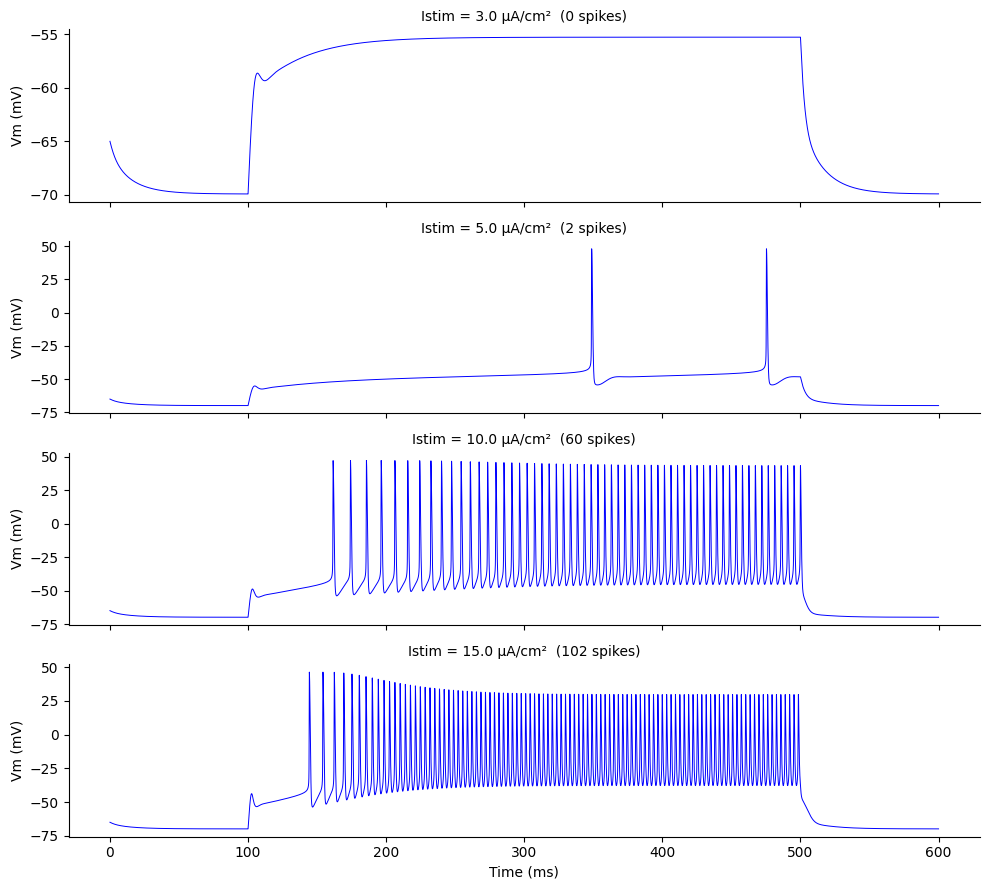

In [ ]:
"""
VGLUT3 (delayed-firing) cell — stimulus sweep.
Same model as before (HH2 with vh=5 h-gate, K_A adaptation, no Ca2+).
Runs several stimulus amplitudes and overlays the voltage traces.
"""

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Cm    = 1.0
g_pas = 9.6e-4
E_pas = -65.0
E_Na  =  50.0
E_K   = -70.0
T_celsius = 36.0
tadj = 3.0 ** ((T_celsius - 36.0) / 10.0)

gNa_max = 85.48
gK_max  = 4.3
vtraub  = -50.2
vh      = 5.0

def hh2_rates(V):
    v2 = V - vtraub
    am = 0.32 * (13.0 - v2) / (np.exp((13.0 - v2) / 4.0) - 1.0)
    bm = 0.28 * (v2 - 40.0) / (np.exp((v2 - 40.0) / 5.0) - 1.0)
    ah = 0.128 * np.exp((17.0 - v2 - vh) / 18.0)
    bh = 4.0 / (1.0 + np.exp((40.0 - v2 - vh) / 5.0))
    an = 0.032 * (15.0 - v2) / (np.exp((15.0 - v2) / 5.0) - 1.0)
    bn = 0.5 * np.exp((10.0 - v2) / 40.0)
    return (am*tadj, bm*tadj, ah*tadj, bh*tadj, an*tadj, bn*tadj)

gKdr_max = 0.111
gKA_max = 10.9
vhalfn = -45.0; zetan = -4.0; gmn = 0.45; a0n = 0.04
vhalfl = -67.0; zetal =  2.0; gml = 1.0;  a0l = 0.023
vhalfm = -67.0; zetam =  4.0
vhalfk = -45.0; zetak = -5.0
F_RT = 9.648e4 / (8.315 * (273.16 + T_celsius))

def borgka_rates(V):
    q10 = 3.0 ** ((T_celsius - 30.0) / 10.0)
    alpn = np.exp(1e-3 * zetan * (V - vhalfn) * F_RT)
    betn = np.exp(1e-3 * zetan * gmn * (V - vhalfn) * F_RT)
    alpk = np.exp(1e-3 * zetak * (V - vhalfk) * F_RT)
    ninf = 1.0 / (1.0 + alpk)
    taun = betn / (q10 * a0n * (1.0 + alpn))
    alpl = np.exp(1e-3 * zetal * (V - vhalfl) * F_RT)
    betl = np.exp(1e-3 * zetal * gml * (V - vhalfl) * F_RT)
    alpm = np.exp(1e-3 * zetam * (V - vhalfm) * F_RT)
    linf = 1.0 / (1.0 + alpm)
    taul = betl / (q10 * a0l * (1.0 + alpl))
    return ninf, taun, linf, taul

def make_rhs(amplitude):
    def stim(t):
        return amplitude if 100.0 <= t < 500.0 else 0.0
    def rhs(t, y):
        V, m, h, n_HH, n_dr, n_KA, l_KA = y
        am, bm, ah, bh, an, bn = hh2_rates(V)
        INa  = gNa_max  * m**3 * h * (V - E_Na)
        IK   = gK_max   * n_HH**4   * (V - E_K)
        IKdr = gKdr_max * n_dr**4   * (V - E_K)
        ninf, taun, linf, taul = borgka_rates(V)
        IKA  = gKA_max * n_KA * l_KA * (V - E_K)
        Ileak = g_pas * (V - E_pas)
        dV = (stim(t) - (INa + IK + IKdr + IKA + Ileak)) / Cm
        return [dV,
                am*(1-m) - bm*m,
                ah*(1-h) - bh*h,
                an*(1-n_HH) - bn*n_HH,
                an*(1-n_dr) - bn*n_dr,
                (ninf - n_KA) / taun,
                (linf - l_KA) / taul]
    return rhs

V0 = -65.0
am0, bm0, ah0, bh0, an0, bn0 = hh2_rates(V0)
ninf0, _, linf0, _ = borgka_rates(V0)
n_HH0 = an0 / (an0 + bn0)
y0 = [V0, am0/(am0+bm0), ah0/(ah0+bh0), n_HH0, n_HH0, ninf0, linf0]

amplitudes = [3.0, 5.0, 10.0, 15.0]
t_eval = np.linspace(0, 600, 24000)

fig, axes = plt.subplots(len(amplitudes), 1, figsize=(10, 9), sharex=True)
for ax, amp in zip(axes, amplitudes):
    sol = solve_ivp(make_rhs(amp), (0, 600), y0, method='RK45',
                    t_eval=t_eval, max_step=0.025, rtol=1e-7, atol=1e-9)
    ax.plot(sol.t, sol.y[0], 'b', lw=0.7)
    n_spikes = int(np.sum((sol.y[0][:-1] < 0) & (sol.y[0][1:] >= 0)))
    ax.set_ylabel('Vm (mV)')
    ax.set_title(f'Istim = {amp} µA/cm²  ({n_spikes} spikes)', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()

# Code Below From Jen

**STEP 1:** altered to match the mods files from NEURON for VLGLUT3


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Jun 16 08:59:09 2026

@author: jcrodelle@middlebury.edu
"""

import numpy as np
import matplotlib.pyplot as plt

def findDeriv(var, par):

    # var holds variables
    v, m_hh, h_hh, n_hh = var #m_bna, h_bna, n_borgka, l_borgka, n_kdri, h_kdri, m_ikca  = var # old n , m , h
    # par holds parameters
    C, g_K_max_hh, g_Na_max_hh, g_L, E_Na, E_K, E_L, Vt, vh, I_ext = par # g_Na_max_bna,g_K_max_borgka, g_K_max_kdri, g_max_ikca,

    # define the rate functions
    #alpha_n = -0.032*(V - Vt - 15) / (np.exp(-(V  - Vt - 15) / 5) - 1)
    #beta_n  = 0.5 * np.exp(-(V - Vt - 10) / 40)
    #alpha_m = -0.32*(V - Vt - 13) / (np.exp(-(V - Vt - 13) / 4) - 1)
    #beta_m  = 0.28 * (V - Vt - 40) / (np.exp((V  - Vt -40) / 5) - 1)
    #alpha_h = 0.128 * np.exp(-(V  - Vt - 17) / 18)
    #beta_h  = 4.0 / (1.0 + np.exp(-(V  - Vt - 40) / 5))

    a_n_hh = 0.32 * (15 - (v - Vt)) / (np.exp((15 - (v - Vt))/5) - 1)
    b_n_hh = 0.5 * np.exp((10 - (v - Vt))/40)

    a_h_hh = 0.128 * np.exp((17 - (v - Vt) -vh) / 18)
    b_h_hh = 4 / (1 + np.exp((40 - (v - Vt))/5))

    a_m_hh = 0.32 * (13 - (v - Vt)) / (np.exp((13 - (v - Vt))/4) - 1)
    b_m_hh = 0.28 * (v - Vt - 40) / (np.exp((v - Vt - 40) / 5) - 1)

     # define derivative of m, n, h
    dndt_hh = a_n_hh*(1 - n_hh ) - b_n_hh*n_hh
    dmdt_hh = a_m_hh*(1 - m_hh ) - b_m_hh*m_hh
    dhdt_hh = a_h_hh*(1 - h_hh ) - b_h_hh*h_hh

    # define conductances
    g_K_hh = g_K_max_hh * (n_hh  ** 4)
    g_Na_hh = g_Na_max_hh * (m_hh  ** 3) * h_hh

    # define currents
    I_Na_hh  = -g_Na_hh * (v - E_Na)
    I_K_hh   = -g_K_hh * (v - E_K)
    I_Leak = -g_L * (v - E_L)

    # derivative for voltage
    dvdt =  (I_Leak + I_Na_hh + I_K_hh + I_ext)*(1/C)
    # combine all derivatives
    derivVars = np.array([dvdt, dndt_hh, dmdt_hh, dhdt_hh])
    return derivVars

"""
Simulation of g_j kinetics in a two FS cell system with 4SM of gap junctions (Cx43).
This HH model is defined in Crodelle 2019
"""

# Simulation time (in ms)
dt = 0.001
duration = 2000
t = np.arange(0, duration + dt, dt)

# number of neurons
N = 1

I_stim = np.zeros((N, len(t)))
I_stim[0, :] = 2.5

# Iterates 300 times to apply periodic current pulses (100 µA/100e-3) to the first cell.
# The pulse is applied in a 2-ms window within every 450-ms period
# for k in range(1, 301):
#     indices = np.where((t > 450 * k) & (t < 450 * k + 2))[0]
#     I_stim[0, indices] = 100e-3


# Initial membrane voltages (-70 mV for both cells)
V = np.full((N, len(t)), -70.0)

# FS cell model parameters
#A = 1         # Cell surface area (mm^2)
C = 1.0         # Membrane capacity (µF/mm^2)
g_L = 0.96e-06  # Leakage conductance (S/cm^2) (not mS/mm^2)
E_L = -65       # Leakage reversal potential (mV)
g_Na_max = 0.08548     # Sodium channel conductance (mho/cm2) (not mS/mm^2)
E_Na = 50       # Sodium reversal potential (mV)
g_K_max = 0.0043;       # Potassium channel conductance mho/cm2 (not mS/mm^2)
E_K = -70       # Potassium reversal potential (mV)
Vt = -50.2          # threshold for rate functions
vh = 5

# Initialize gating variable arrays
# n: K activation, m: Na activation, h: Na inactivation
a_n_hh = np.zeros((N, len(t)-1))
b_n_hh  = np.zeros((N, len(t)-1))
a_m_hh = np.zeros((N, len(t)-1))
b_m_hh  = np.zeros((N, len(t)-1))
a_h_hh = np.zeros((N, len(t)-1))
b_h_hh  = np.zeros((N, len(t)-1))
m_hh = np.zeros((N, len(t)))
h_hh = np.zeros((N, len(t)))
n_hh = np.zeros((N, len(t)))



# Simulation
for i in range(len(t) - 1):

    for j in range(N):
        # Compute transition rates for the gating variables
        V_current = V[j, i]
        n_current = n_hh[j, i]
        m_current = m_hh[j, i]
        h_current = h_hh[j, i]
        # variable array for passing into derivative
        var = np.array([V_current, n_current, m_current, h_current ])


        # parameters for the HH voltage model
        Vpars = np.array([C, g_Na_max, g_L, g_K_max, E_Na, E_K, E_L, Vt, vh, I_stim[j, i]])

        # evaluate derivative using RK4
        K1 = var
        K2 = var + (dt/2)*findDeriv(K1,Vpars)
        K3 = var + (dt/2)*findDeriv(K2, Vpars)
        K4 = var + dt*findDeriv(K3, Vpars)
        newVar = var + (dt/6)*(findDeriv(K1, Vpars) + 2*findDeriv(K2, Vpars) + 2*findDeriv(K3, Vpars) + findDeriv(K4,Vpars))
        # Euler's method
       # newVar = var + dt*findDeriv(var,Vpars)
        # update variables
        V[j, i+1] = newVar[0]
        n_hh[j, i+1] = newVar[1]
        m_hh[j, i+1] = newVar[2]
        h_hh[j, i+1] = newVar[3]

/tmp/ipykernel_5677/1582749222.py:27: RuntimeWarning: overflow encountered in exp
  a_n_hh = 0.32 * (15 - (v - Vt)) / (np.exp((15 - (v - Vt))/5) - 1)
/tmp/ipykernel_5677/1582749222.py:28: RuntimeWarning: overflow encountered in exp
  b_n_hh = 0.5 * np.exp((10 - (v - Vt))/40)
/tmp/ipykernel_5677/1582749222.py:30: RuntimeWarning: overflow encountered in exp
  a_h_hh = 0.128 * np.exp((17 - (v - Vt) -vh) / 18)
/tmp/ipykernel_5677/1582749222.py:31: RuntimeWarning: overflow encountered in exp
  b_h_hh = 4 / (1 + np.exp((40 - (v - Vt))/5))
/tmp/ipykernel_5677/1582749222.py:33: RuntimeWarning: overflow encountered in exp
  a_m_hh = 0.32 * (13 - (v - Vt)) / (np.exp((13 - (v - Vt))/4) - 1)
/tmp/ipykernel_5677/1582749222.py:34: RuntimeWarning: overflow encountered in exp
  b_m_hh = 0.28 * (v - Vt - 40) / (np.exp((v - Vt - 40) / 5) - 1)
/tmp/ipykernel_5677/1582749222.py:37: RuntimeWarning: invalid value encountered in scalar multiply
  dndt_hh = a_n_hh*(1 - n_hh ) - b_n_hh*n_hh
/tmp/ipykernel_5677

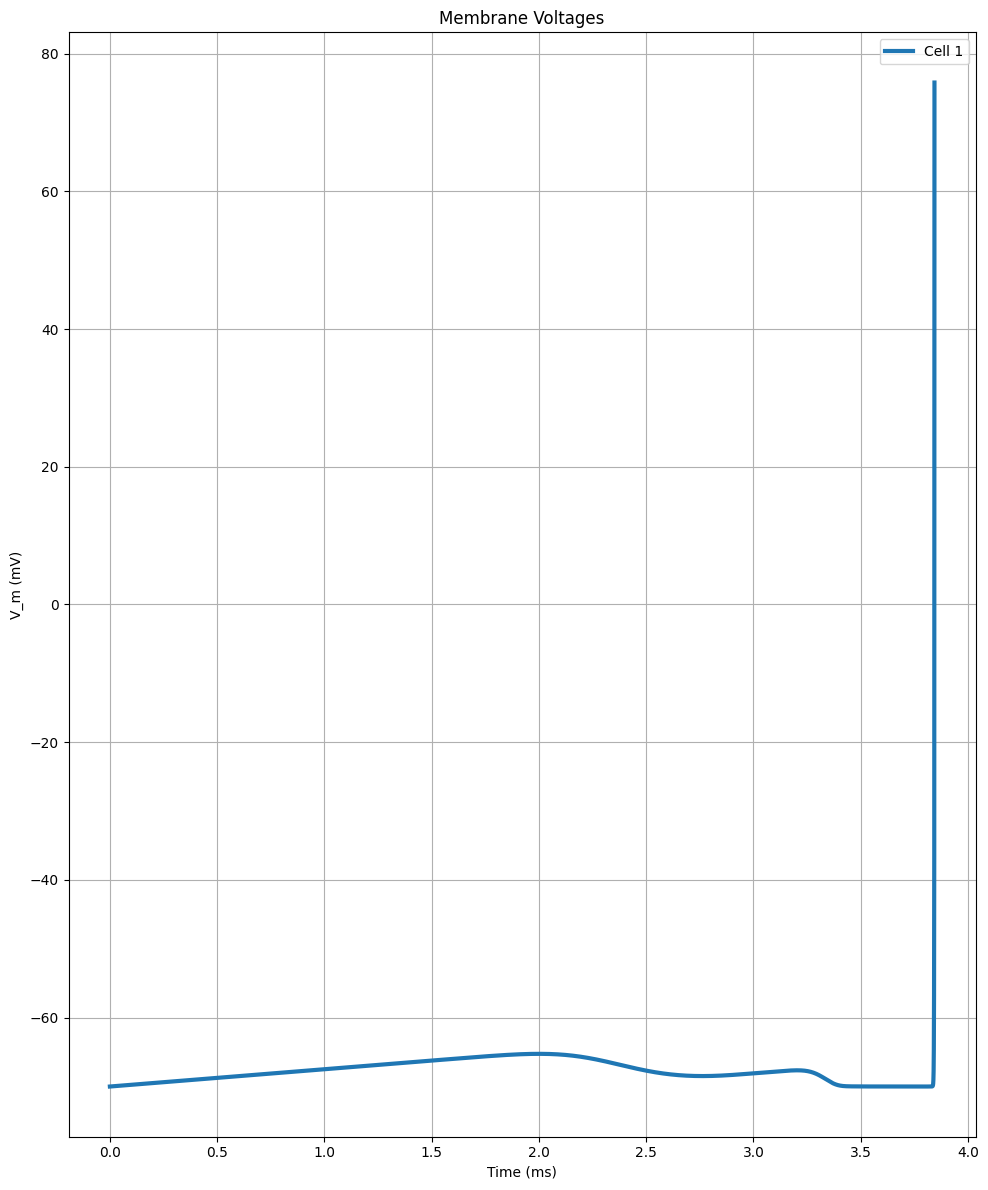

In [ ]:
# Visualization
plt.figure(figsize=(10, 12))

# Plot Vm/membrane voltages for both cells
plt.plot(t, V[0, :], linewidth=3, label='Cell 1')
plt.xlabel('Time (ms)')
plt.ylabel('V_m (mV)')
#plt.axis([10,50,-70,50])
plt.title('Membrane Voltages')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

# **VGLUT3 Neuron modeling**


## 1. Directly from original model (3 compartment)

In [ ]:
#setting up notebook
!pip install neuron netpyne
from netpyne import specs, sim

from google.colab import drive
drive.mount('/content/drive')

!nrnivmodl /content/drive/MyDrive/Summer_2026_Research/mods
from neuron import h, load_mechanisms
load_mechanisms('/content/drive/MyDrive/Summer_2026_Research/mods')


In [ ]:
# makes dictionary of traits for VGLUT
EXdelayedRule  = {
 'conds': {},
 'globals': {},
 'secLists': {},
 'secs': {'dend': {'geom': {'L': 400.0, 'nseg': 5, 'diam': 3.0, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'CaIntraCellDyn': {'cai_inf': 5e-05, 'cai_tau': 2.0, 'depth': 0.1},
                             'HH2': {'gnabar': 0.0, 'gkbar': 0.144, 'vtraub': -50.2},
                             'iKCa': {'gbar': 0.002, 'gk': 0.0},
                             'borgka': {'gkabar': 0.0009333},
                             'KDRI': {'gkbar': 0.96e-05},
                             'pas': {'g': 0.96e-06, 'e': -65.0}},
                   'topol': {'parentSec': 'soma', 'parentX': 0.0, 'childX': 0.0}},
          'hillock': {'geom': {'L': 9.0, 'nseg': 3, 'diam': 1.5, 'Ra': 150.0, 'cm': 1.0},
                      'ions': {'k': {'e': -77.0, 'i': 54.4, 'o': 2.5},
                               'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                      'mechs': {'B_Na': {'gnabar': 0.03, 'alpha_shift': 0.0, 'beta_shift': 0.0},
                                'HH2': {'gkbar': 0.304, 'gnabar': 0.02375, 'vtraub': -50.2},
                                'borgka': {'gkabar': 0.1120 * 1.0 },
                                'KDRI': {'gkbar': 0.01547},
                                'pas': {'g': 0.96e-06, 'e': -65.0}},
                      'topol': {'parentSec': 'soma', 'parentX': 1.0, 'childX': 0.0}},
          'soma': {'geom': {'L': 20.0, 'nseg': 3, 'diam': 20.0, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'B_Na': {'gnabar': 0.0001652, 'alpha_shift': 0.0, 'beta_shift': 0.0},
                             'CaIntraCellDyn': {'cai_inf': 5e-05, 'cai_tau': 1.0, 'depth': 0.1},
                             'HH2': {'gkbar': 0.0043, 'gnabar': 0.08548, 'vtraub': -50.2},
                             'borgka': {'gkabar': 0.01090 * 1.0 },
                             'KDRI': {'gkbar': 0.0001110},
                             'iKCa': {'gbar': 0.002, 'gk': 0.0},
                             'pas': {'g': 0.96e-06, 'e': -65.0}},
                   'topol': {}}}
}

In [ ]:
netParams = specs.NetParams() # for easy of typing
EXdelayedRule['conds'] = {'cellType': 'EXdl'}
netParams.cellParams['VGLUT3Rule'] = EXdelayedRule #sets the parameters to above dictionary
netParams.popParams['VGLUT3'] = {'cellType': 'EXdl', 'numCells': 1} # VGLUT3+ neurons (excitatory) -> creates one ceel of VLUT3

# settings for the input
netParams.stimSourceParams['input'] = {
    'type': 'IClamp',
    'del': 0,     # ms: rest first, so you can see baseline
    'dur': 1900,     # ms: then hold the current on for the rest of the run
    'amp': .7}     # nA: the constant input level  <-- the knob to change


#
netParams.stimTargetParams['input->VGLUT3'] = {
    'source': 'input', 'conds': {'pop': 'VGLUT3'},
    'sec': 'dend', 'loc': 0.5}



Start time:  2026-06-18 12:38:43.732414




Creating network of 1 cell populations on 1 hosts...:   0%|          |
Creating network of 1 cell populations on 1 hosts...: 100%|##########|

ERROR: Some mechanisms and/or ions were not inserted (for details run with cfg.verbose=True). Make sure the required mod files are compiled.
  Number of cells on node 0: 1 
  Done; cell creation time = 0.02 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 1 
  Done; cell stims creation time = 0.00 s.
Recording 1 traces of 1 types on node 0

Running simulation using NEURON for 2000.0 ms...


  Done; run time = 0.20 s; real-time ratio: 9.94.

Gathering data...
  Done; gather time = 0.00 s.

Analyzing...
  Cells: 1
  Connections: 0 (0.00 per cell)
  Spikes: 1 (0.50 Hz)
  Simulated time: 2.0 s; 1 workers
  Run time: 0.20 s
Saving output as data/model_output_data.json ... 
Finished saving!
  Done; saving time = 0.13 s.
Plotting recorded cell traces ... cell


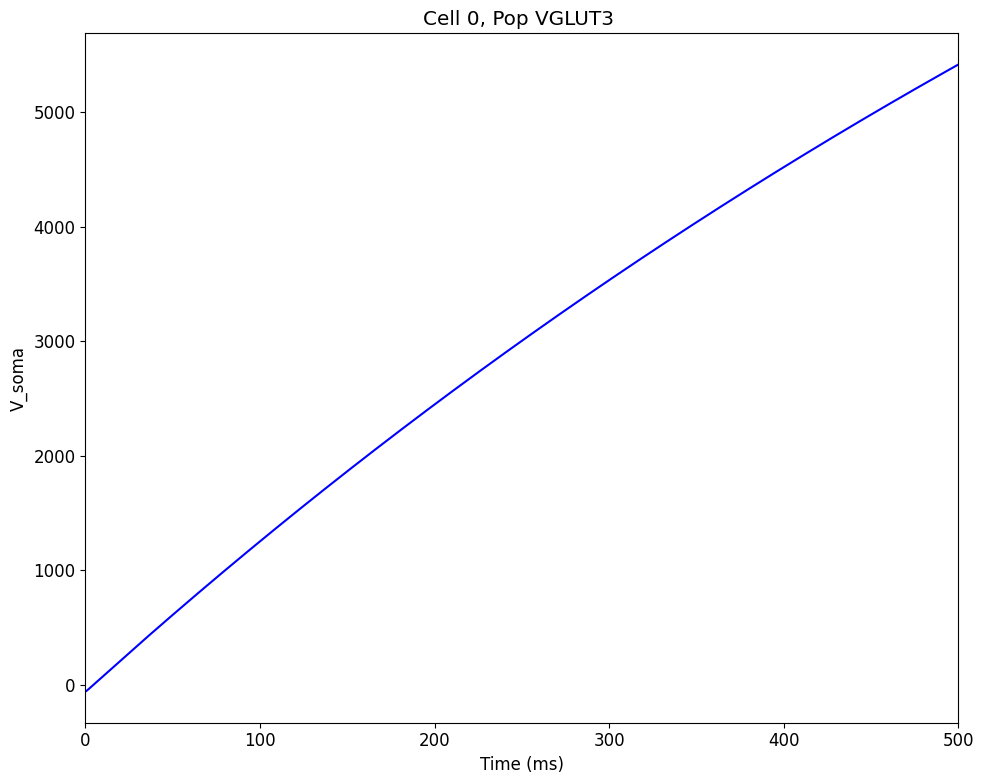

  Done; plotting time = 0.58 s

Total time = 0.94 s


In [ ]:
 # ---- run settings ---- all claude here need to return
cfg = specs.SimConfig()
cfg.hParams    = {'celsius': 36, 'v_init': -60}
cfg.duration   = 2000      # ms
cfg.dt         = 0.025
cfg.recordStep = 0.1
cfg.saveFolder = 'data'     # where output goes
cfg.saveJson   = True       # save results (also clears the "won't be saved" warning)
cfg.recordTraces['V_soma'] = {'sec': 'soma', 'loc': 0.5, 'var': 'v'}

# note measures loc. 0.5 on each, but unclear what actual model does should check
%matplotlib inline
cfg.analysis['plotTraces'] = {
    'include': [0],
    'timeRange': [0, 500],     # zoom the x-axis to 100-140 ms
    'saveFig': True, 'showFig': True}

sim.createSimulateAnalyze(netParams=netParams, simConfig=cfg)

In [ ]:
print(sim.net.allCells[0]['tags'])              # confirm a cell exists at index 0
print(list(sim.simData.keys()))                 # are V_soma / V_dend / V_hillock present?
print(len(sim.simData['V_soma'].get('cell_0', []) if 'V_soma' in sim.simData else 'no V_soma'))
print(sim.net.cells[0].secs.keys())


{cellType: 'EXdl', pop: 'VGLUT3', xnorm: np.float64(0.3583531143706401), ynorm: np.float64(0.3984944342173416), znorm: np.float64(0.8763654583887277), x: np.float64(35.83531143706401), y: np.float64(39.84944342173416), z: np.float64(87.63654583887276), label: ['VGLUT3Rule']}
['spkt', 'spkid', 'V_soma', 't']
20001
dict_keys(['dend', 'hillock', 'soma'])


# **2.** **Simplifying to 1 compartment**

## 2a. delete hillock and dend without changing soma

result: constantly increasing voltage

In [ ]:
# contains removed information for EXsimpleDelayedRule
"""
'dend': {'geom': {'L': 400.0, 'nseg': 5, 'diam': 3.0, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'CaIntraCellDyn': {'cai_inf': 5e-05, 'cai_tau': 2.0, 'depth': 0.1},
                             'HH2': {'gnabar': 0.0, 'gkbar': 0.144, 'vtraub': -50.2},
                             'iKCa': {'gbar': 0.002, 'gk': 0.0},
                             'borgka': {'gkabar': 0.0009333},
                             'KDRI': {'gkbar': 0.96e-05},
                             'pas': {'g': 0.96e-06, 'e': -65.0}},
                   'topol': {'parentSec': 'soma', 'parentX': 0.0, 'childX': 0.0}},
          'hillock': {'geom': {'L': 9.0, 'nseg': 3, 'diam': 1.5, 'Ra': 150.0, 'cm': 1.0},
                      'ions': {'k': {'e': -77.0, 'i': 54.4, 'o': 2.5},
                               'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                      'mechs': {'B_Na': {'gnabar': 0.03, 'alpha_shift': 0.0, 'beta_shift': 0.0},
                                'HH2': {'gkbar': 0.304, 'gnabar': 0.02375, 'vtraub': -50.2},
                                'borgka': {'gkabar': 0.1120 * 1.0 },
                                'KDRI': {'gkbar': 0.01547},
                                'pas': {'g': 0.96e-06, 'e': -65.0}},
                      'topol': {'parentSec': 'soma', 'parentX': 1.0, 'childX': 0.0}},
"""

"\n'dend': {'geom': {'L': 400.0, 'nseg': 5, 'diam': 3.0, 'Ra': 150.0, 'cm': 1.0}, \n                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},\n                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},\n                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},\n                   'mechs': {'CaIntraCellDyn': {'cai_inf': 5e-05, 'cai_tau': 2.0, 'depth': 0.1},\n                             'HH2': {'gnabar': 0.0, 'gkbar': 0.144, 'vtraub': -50.2},\n                             'iKCa': {'gbar': 0.002, 'gk': 0.0},\n                             'borgka': {'gkabar': 0.0009333},\n                             'KDRI': {'gkbar': 0.96e-05},\n                             'pas': {'g': 0.96e-06, 'e': -65.0}},\n                   'topol': {'parentSec': 'soma', 'parentX': 0.0, 'childX': 0.0}},\n          'hillock': {'geom': {'L': 9.0, 'nseg': 3, 'diam': 1.5, 'Ra': 150.0, 'cm': 1.0},\n                      'ions': {'k': {'e': -77.0, 'i': 54.4, 'o': 2.5},\n     

In [ ]:
# makes dictionary of traits for VGLUT with only soma
#directly deletes dend and hillock without changing soa
EXdelayedRule1compa  = {
 'conds': {},
 'globals': {},
 'secLists': {},
 'secs': {'soma': {'geom': {'L': 20.0, 'nseg': 3, 'diam': 20.0, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'B_Na': {'gnabar': 0.0001652, 'alpha_shift': 0.0, 'beta_shift': 0.0},
                             'CaIntraCellDyn': {'cai_inf': 5e-05, 'cai_tau': 1.0, 'depth': 0.1},
                             'HH2': {'gkbar': 0.0043, 'gnabar': 0.08548, 'vtraub': -50.2},
                             'borgka': {'gkabar': 0.01090 * 1.0 },
                             'KDRI': {'gkbar': 0.0001110},
                             'iKCa': {'gbar': 0.002, 'gk': 0.0},
                             'pas': {'g': 0.96e-06, 'e': -65.0}},
                   'topol': {}}}
}

NameError: name 'soma' is not defined

In [ ]:
netParams = specs.NetParams() # for easy of typing
EXdelayedRule1compa['conds'] = {'cellType': 'EXdl1ca'}
netParams.cellParams['VGLUT3Rule1compa'] = EXdelayedRule1compa #sets the parameters to above dictionary
netParams.popParams['VGLUT3'] = {'cellType': 'EXdl1ca', 'numCells': 1} # VGLUT3+ neurons (excitatory) -> creates one ceel of VLUT3

# settings for the input
netParams.stimSourceParams['input'] = {
    'type': 'IClamp',
    'del': 0,     # ms: rest first, so you can see baseline
    'dur': 2000,     # ms: then hold the current on for the rest of the run
    'amp': .1}     # nA: the constant input level  <-- the knob to change


#
netParams.stimTargetParams['input->VGLUT3'] = {
    'source': 'input', 'conds': {'pop': 'VGLUT3'},
    'sec': 'soma', 'loc': 0.5}



Start time:  2026-06-18 13:25:03.534744




Creating network of 1 cell populations on 1 hosts...:   0%|          |
Creating network of 1 cell populations on 1 hosts...: 100%|##########|

ERROR: Some mechanisms and/or ions were not inserted (for details run with cfg.verbose=True). Make sure the required mod files are compiled.
  Number of cells on node 0: 1 
  Done; cell creation time = 0.01 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 1 
  Done; cell stims creation time = 0.00 s.
Recording 1 traces of 1 types on node 0

Running simulation using NEURON for 2000.0 ms...
  Done; run time = 0.08 s; real-time ratio: 24.29.

Gathering data...
  Done; gather time = 0.00 s.

Analyzing...
  Cells: 1
  Connections: 0 (0.00 per cell)
  Spikes: 1 (0.50 Hz)
  Simulated time: 2.0 s; 1 workers
  Run time: 0.08 s
Saving output as data/model_output_data.json ... 
Finished saving!
  Done; saving time = 0.03 s.
Plotting recorded cell traces ... cell


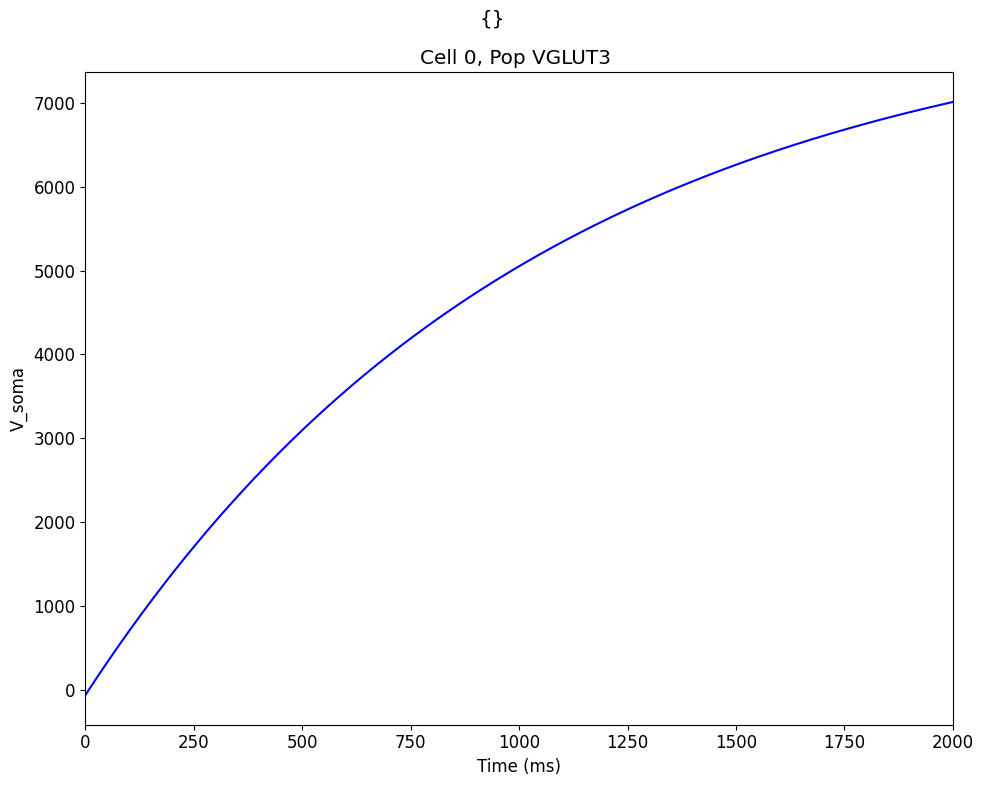

  Done; plotting time = 0.26 s

Total time = 0.38 s


In [ ]:
 # ---- run settings ---- all claude here need to return
cfg = specs.SimConfig()
cfg.hParams    = {'celsius': 36, 'v_init': -60}
cfg.duration   = 2000      # ms
cfg.dt         = 0.025
cfg.recordStep = 0.1
cfg.saveFolder = 'data'     # where output goes
cfg.saveJson   = True       # save results (also clears the "won't be saved" warning)
cfg.recordTraces['V_soma'] = {'sec': 'soma', 'loc': 0.5, 'var': 'v'}

# note measures loc. 0.5 on each, but unclear what actual model does should check
%matplotlib inline
cfg.analysis['plotTraces'] = {
    'include': [0],
    'timeRange': [0, 2000],     # zoom the x-axis to 100-140 ms
    'saveFig': True, 'showFig': True}

sim.createSimulateAnalyze(netParams=netParams, simConfig=cfg)

## 2b. delete hillock and dend and change soma geometric properties


In [ ]:
# makes dictionary of traits for VGLUT with only soma
#directly deletes dend and hillock without changing soa
EXdelayedRule1compb  = {
 'conds': {},
 'globals': {},
 'secLists': {},
 'secs': {'soma': {'geom': {'L': 80.6, 'nseg': 1, 'diam': 20, 'Ra': 150.0, 'cm': 1.0}, # L = 400 (d) + 9 (h) + 20 (s). diam = (3 + 1.5 + 20)/3 Ra (axial resistivity) = 150 (same for all) cm = 1 (same for all)
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'B_Na': {'gnabar': 0.0001652, 'alpha_shift': 0.0, 'beta_shift': 0.0},
                             'CaIntraCellDyn': {'cai_inf': 5e-05, 'cai_tau': 1.0, 'depth': 0.1},
                             'HH2': {'gkbar': 0.0043, 'gnabar': 0.08548, 'vtraub': -50.2},
                             'borgka': {'gkabar': 0.01090 * 1.0 },
                             'KDRI': {'gkbar': 0.0001110},
                             'iKCa': {'gbar': 0.002, 'gk': 0.0},
                             'pas': {'g': 0.96e-06, 'e': -65.0}},
                   'topol': {}}}
}

In [ ]:
netParams = specs.NetParams() # for easy of typing
EXdelayedRule1compb['conds'] = {'cellType': 'EXdl1cb'}
netParams.cellParams['VGLUT3Rule1compb'] = EXdelayedRule1compb #sets the parameters to above dictionary
netParams.popParams['VGLUT3'] = {'cellType': 'EXdl1cb', 'numCells': 1} # VGLUT3+ neurons (excitatory) -> creates one ceel of VLUT3

# settings for the input
netParams.stimSourceParams['input'] = {
    'type': 'IClamp',
    'del': 0,     # ms: rest first, so you can see baseline
    'dur': 2000,     # ms: then hold the current on for the rest of the run
    'amp': .1}     # nA: the constant input level  <-- the knob to change


#
netParams.stimTargetParams['input->VGLUT3'] = {
    'source': 'input', 'conds': {'pop': 'VGLUT3'},
    'sec': 'soma', 'loc': 0.5}



Start time:  2026-06-18 14:10:21.341215




Creating network of 1 cell populations on 1 hosts...:   0%|          |
Creating network of 1 cell populations on 1 hosts...: 100%|##########|

ERROR: Some mechanisms and/or ions were not inserted (for details run with cfg.verbose=True). Make sure the required mod files are compiled.
  Number of cells on node 0: 1 
  Done; cell creation time = 0.01 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 1 
  Done; cell stims creation time = 0.00 s.
Recording 1 traces of 1 types on node 0

Running simulation using NEURON for 2000.0 ms...
  Done; run time = 0.08 s; real-time ratio: 24.64.

Gathering data...
  Done; gather time = 0.00 s.

Analyzing...
  Cells: 1
  Connections: 0 (0.00 per cell)
  Spikes: 1 (0.50 Hz)
  Simulated time: 2.0 s; 1 workers
  Run time: 0.08 s
Saving output as data/model_output_data.json ... 
Finished saving!
  Done; saving time = 0.04 s.
Plotting recorded cell traces ... cell


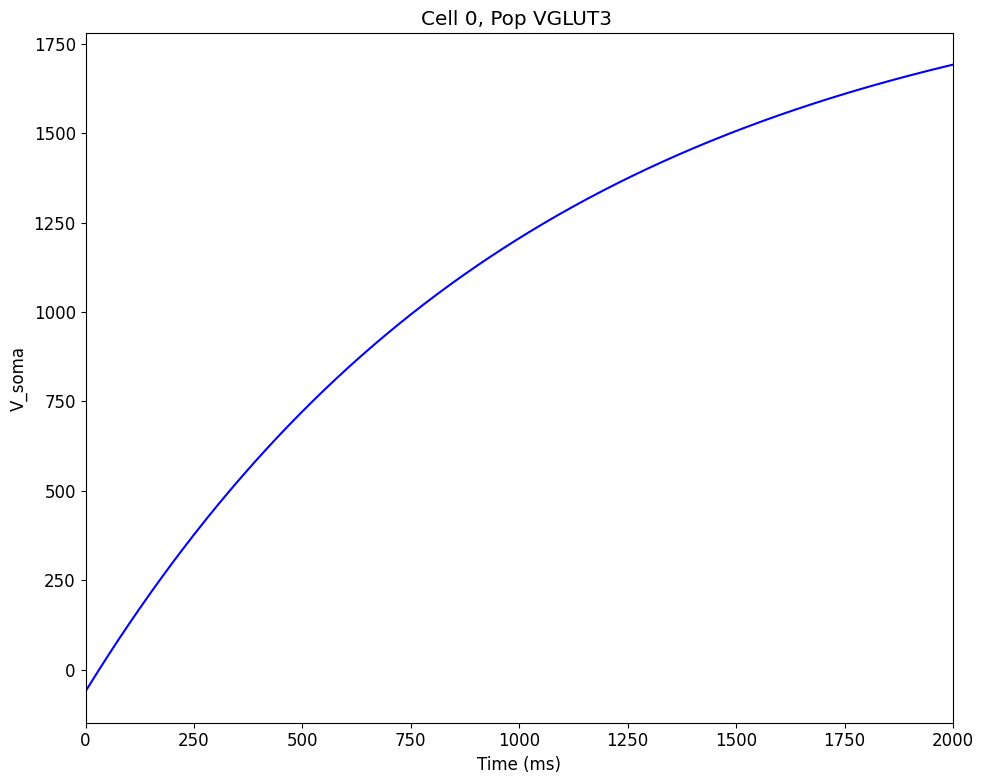

  Done; plotting time = 0.29 s

Total time = 0.42 s


In [ ]:
 # ---- run settings ---- all claude here need to return
cfg = specs.SimConfig()
cfg.hParams    = {'celsius': 36, 'v_init': -60}
cfg.duration   = 2000      # ms
cfg.dt         = 0.025
cfg.recordStep = 0.1
cfg.saveFolder = 'data'     # where output goes
cfg.saveJson   = True       # save results (also clears the "won't be saved" warning)
cfg.recordTraces['V_soma'] = {'sec': 'soma', 'loc': 0.5, 'var': 'v'}

# note measures loc. 0.5 on each, but unclear what actual model does should check
%matplotlib inline
cfg.analysis['plotTraces'] = {
    'include': [0],
    'timeRange': [0, 2000],     # zoom the x-axis to 100-140 ms
    'saveFig': True, 'showFig': True}

sim.createSimulateAnalyze(netParams=netParams, simConfig=cfg)

In [ ]:
# code to calculate surface areas

# surface area of soma
soma = h.Section(name='soma')
soma.L = 20        # Length in micrometers
soma.diam = 20     # Diameter in micrometers

# Calculate surface area at the center of the soma
# The argument 0.5 represents the normalized distance (0 to 1)
area_center_s = soma(0.5).area()
print(f"Soma surface area: {area_center_s} um2")

# surface area of dend
dend = h.Section(name='dend')
dend.L = 400        # Length in micrometers
dend.diam = 3     # Diameter in micrometers

# Calculate surface area at the center of the dend
area_center_d = dend(0.5).area()
print(f"Dendrites surface area: {area_center_d} um2")

# surface area of hillock
hill = h.Section(name='hillock')
hill.L = 9        # Length in micrometers
hill.diam = 1.5     # Diameter in micrometers

# Calculate surface area at the center of the hillock
area_center_h = hill(0.5).area()
print(f"Hillock surface area: {area_center_h} um2")

print(f"total are of soma, hillock, and dendrites: {area_center_h + area_center_d + area_center_s}")

# surface area of new soma:
new_soma = h.Section(name='new_soma')
new_soma.L = 80.6        # Length in micrometers
new_soma.diam = 20     # Diameter in micrometers
area_center = new_soma(0.5).area()
print(f"New soma surface area: {area_center} um2")

Soma surface area: 1256.6370614359173 um2
Dendrites surface area: 3769.9111843077517 um2
Hillock surface area: 42.411500823462205 um2
total are of soma, hillock, and dendrites: 5068.959746567131
New soma surface area: 5064.247357586746 um2


## 2c. change geometry and conductances of soma



Start time:  2026-06-18 14:38:38.979984




Creating network of 1 cell populations on 1 hosts...:   0%|          |
Creating network of 1 cell populations on 1 hosts...: 100%|##########|

ERROR: Some mechanisms and/or ions were not inserted (for details run with cfg.verbose=True). Make sure the required mod files are compiled.
  Number of cells on node 0: 1 
  Done; cell creation time = 0.01 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 1 
  Done; cell stims creation time = 0.00 s.
Recording 1 traces of 1 types on node 0

Running simulation using NEURON for 2000.0 ms...
  Done; run time = 0.08 s; real-time ratio: 24.72.

Gathering data...
  Done; gather time = 0.00 s.

Analyzing...
  Cells: 1
  Connections: 0 (0.00 per cell)
  Spikes: 1 (0.50 Hz)
  Simulated time: 2.0 s; 1 workers
  Run time: 0.08 s
Saving output as data/model_output_data.json ... 
Finished saving!
  Done; saving time = 0.04 s.
Plotting recorded cell traces ... cell


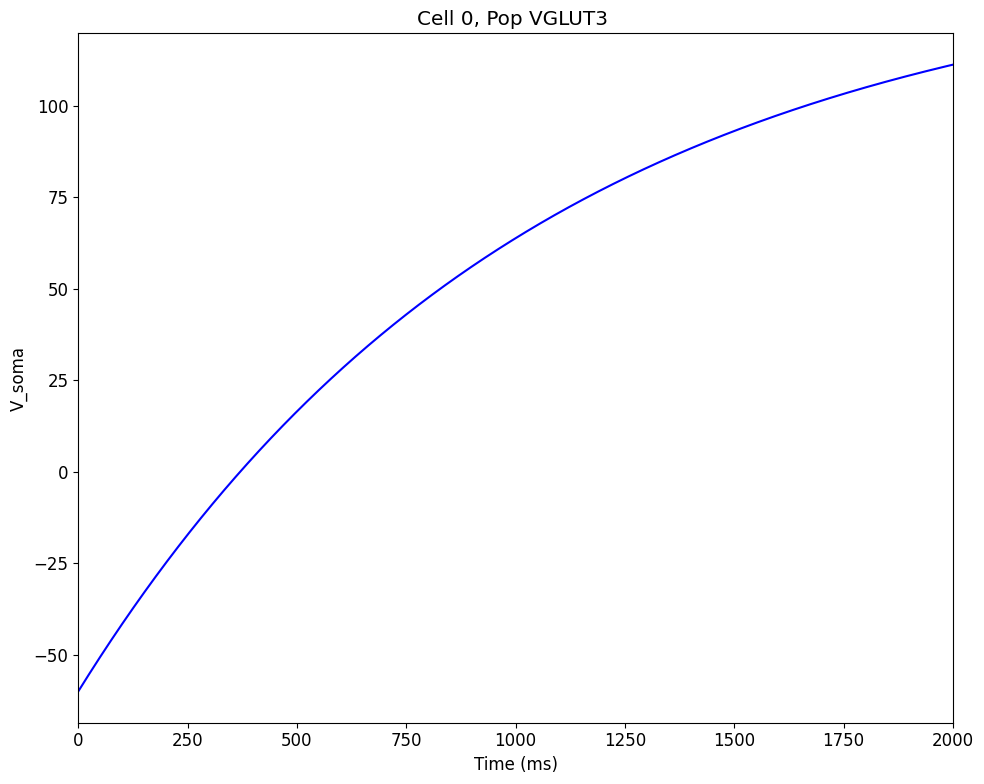

  Done; plotting time = 0.26 s

Total time = 0.39 s


In [ ]:
# makes dictionary of traits for VGLUT with only soma
#directly deletes dend and hillock without changing soa
EXdelayedRule1compc  = {
 'conds': {},
 'globals': {},
 'secLists': {},
 'secs': {'soma': {'geom': {'L': 80.6, 'nseg': 1, 'diam': 20, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'ca': {'e': 132.4579341637009, 'i': 5e-05, 'o': 2.0},
                            'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'B_Na': {'gnabar': 0.0001652, 'alpha_shift': 0.0, 'beta_shift': 0.0},
                             'CaIntraCellDyn': {'cai_inf': 5e-05, 'cai_tau': 1.0, 'depth': 0.1},
                             'HH2': {'gkbar': 0.043, 'gnabar': 0.08548, 'vtraub': -50.2},
                             'borgka': {'gkabar': 0.0109 * 1.0 },
                             'KDRI': {'gkbar': 0.000111},
                             'iKCa': {'gbar': 0.002, 'gk': 0.0},
                             'pas': {'g': 0.96e-6, 'e': -65.0}},
                   'topol': {}}}
}

netParams = specs.NetParams() # for easy of typing
EXdelayedRule1compc['conds'] = {'cellType': 'EXdl1cc'}
netParams.cellParams['VGLUT3Rule1compc'] = EXdelayedRule1compc #sets the parameters to above dictionary
netParams.popParams['VGLUT3'] = {'cellType': 'EXdl1cc', 'numCells': 1} # VGLUT3+ neurons (excitatory) -> creates one ceel of VLUT3

# settings for the input
netParams.stimSourceParams['input'] = {
    'type': 'IClamp',
    'del': 0,     # ms: rest first, so you can see baseline
    'dur': 2000,     # ms: then hold the current on for the rest of the run
    'amp': .01}     # nA: the constant input level  <-- the knob to change


#
netParams.stimTargetParams['input->VGLUT3'] = {
    'source': 'input', 'conds': {'pop': 'VGLUT3'},
    'sec': 'soma', 'loc': 0.5}

# ---- run settings ---- all claude here need to return
cfg = specs.SimConfig()
cfg.hParams    = {'celsius': 36, 'v_init': -60}
cfg.duration   = 2000      # ms
cfg.dt         = 0.025
cfg.recordStep = 0.1
cfg.saveFolder = 'data'     # where output goes
cfg.saveJson   = True       # save results (also clears the "won't be saved" warning)
cfg.recordTraces['V_soma'] = {'sec': 'soma', 'loc': 0.5, 'var': 'v'}

# note measures loc. 0.5 on each, but unclear what actual model does should check
%matplotlib inline
cfg.analysis['plotTraces'] = {
    'include': [0],
    'timeRange': [0, 2000],     # zoom the x-axis to 100-140 ms
    'saveFig': True, 'showFig': True}

sim.createSimulateAnalyze(netParams=netParams, simConfig=cfg)


# New single compartment model attempt -> not from paper


Start time:  2026-06-18 14:44:10.172985




Creating network of 1 cell populations on 1 hosts...:   0%|          |
Creating network of 1 cell populations on 1 hosts...: 100%|##########|

ERROR: Some mechanisms and/or ions were not inserted (for details run with cfg.verbose=True). Make sure the required mod files are compiled.
  Number of cells on node 0: 1 
  Done; cell creation time = 0.01 s.
Making connections...
  Number of connections on node 0: 0 
  Done; cell connection time = 0.00 s.
Adding stims...
  Number of stims on node 0: 1 
  Done; cell stims creation time = 0.00 s.
Recording 1 traces of 1 types on node 0

Running simulation using NEURON for 2000.0 ms...
  Done; run time = 0.08 s; real-time ratio: 24.16.

Gathering data...
  Done; gather time = 0.00 s.

Analyzing...
  Cells: 1
  Connections: 0 (0.00 per cell)
  Spikes: 0 (0.00 Hz)
  Simulated time: 2.0 s; 1 workers
  Run time: 0.08 s
Saving output as data/model_output_data.json ... 
Finished saving!
  Done; saving time = 0.04 s.
Plotting recorded cell traces ... cell


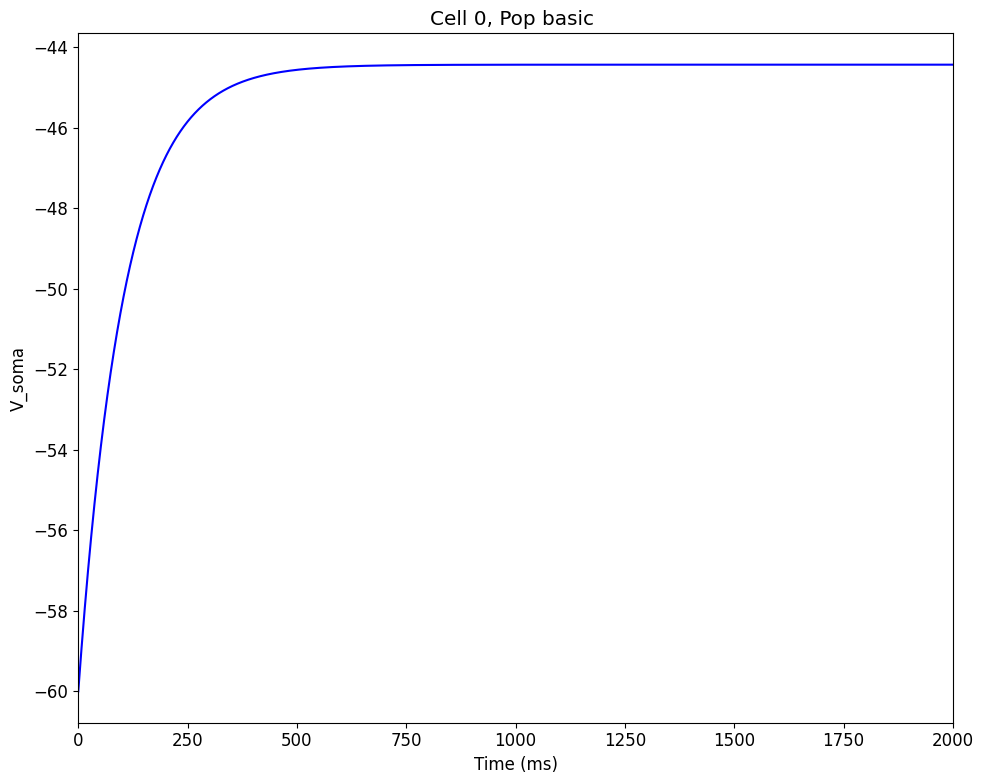

  Done; plotting time = 0.50 s

Total time = 0.63 s


In [102]:
# makes dictionary of traits for VGLUT with only soma
#directly deletes dend and hillock without changing soa
Rule1comp  = {
 'conds': {},
 'globals': {},
 'secLists': {},
 'secs': {'soma': {'geom': {'L': 80.6, 'nseg': 1, 'diam': 20, 'Ra': 150.0, 'cm': 1.0},
                   'ions': {'k': {'e': -70.0, 'i': 54.4, 'o': 2.5},
                            'na': {'e': 50.0, 'i': 10.0, 'o': 140.0}},
                   'mechs': {'HH2': {'gkbar': 0.043, 'gnabar': 0.08548, 'vtraub': -50.2},
                             'pas': {'g': 0.96e-5, 'e': -65.0}},
                   'topol': {}}}
}

netParams = specs.NetParams() # for easy of typing
Rule1comp['conds'] = {'cellType': 'basic'}
netParams.cellParams['basicRule'] = Rule1comp #sets the parameters to above dictionary
netParams.popParams['basic'] = {'cellType': 'basic', 'numCells': 1} # VGLUT3+ neurons (excitatory) -> creates one ceel of VLUT3

# settings for the input
netParams.stimSourceParams['input'] = {
    'type': 'IClamp',
    'del': 0,     # ms: rest first, so you can see baseline
    'dur': 2000,     # ms: then hold the current on for the rest of the run
    'amp': .01}     # nA: the constant input level  <-- the knob to change


#
netParams.stimTargetParams['input->basic'] = {
    'source': 'input', 'conds': {'pop': 'basic'},
    'sec': 'soma', 'loc': 0.5}

# ---- run settings ---- all claude here need to return
cfg = specs.SimConfig()
cfg.hParams    = {'celsius': 36, 'v_init': -60}
cfg.duration   = 2000      # ms
cfg.dt         = 0.025
cfg.recordStep = 0.1
cfg.saveFolder = 'data'     # where output goes
cfg.saveJson   = True       # save results (also clears the "won't be saved" warning)
cfg.recordTraces['V_soma'] = {'sec': 'soma', 'loc': 0.5, 'var': 'v'}

# note measures loc. 0.5 on each, but unclear what actual model does should check
%matplotlib inline
cfg.analysis['plotTraces'] = {
    'include': [0],
    'timeRange': [0, 2000],     # zoom the x-axis to 100-140 ms
    'saveFig': True, 'showFig': True}

sim.createSimulateAnalyze(netParams=netParams, simConfig=cfg)
